# Section 2 - Python Data Processing and Integrated Analysis

The focus is on importing cleaned NorthStar datasets from GitHub, combining the data into one consolidated dataframe, checking data integrity, analysing the dataset using Pandas and NumPy, creating engineered features, and producing numerical visualisations


## Importing required python libraries

The required Python libraries for numerical analysis, data processing, and visualisation are imported. Matplotlib and Seaborn are used to build visualisations for exploratory data analysis, NumPy is used for numerical computations, and Pandas is used to work with dataframes


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

print("Python libraries imported successfully.")

Python libraries imported successfully.


## Importing cleaned NorthStar dataset files from GitHub

The 'datasets/cleaned/` folder on the GitHub repository contains the cleaned NorthStar datasets. Using their raw GitHub URL, the cleaned files are imported straight into in this section


In [2]:
base_url = "https://raw.githubusercontent.com/jagan-002/northstar-database-analytics-coursework/main/datasets/cleaned/"

app_events = pd.read_csv(base_url + "cleaned_app_events.csv")
complaints = pd.read_csv(base_url + "cleaned_complaints.csv")
customers = pd.read_csv(base_url + "cleaned_customers.csv")
deliveries = pd.read_csv(base_url + "cleaned_deliveries.csv")
drivers = pd.read_csv(base_url + "cleaned_drivers.csv")
hubs = pd.read_csv(base_url + "cleaned_hubs.csv")
incidents = pd.read_csv(base_url + "cleaned_incidents.csv")
orders = pd.read_csv(base_url + "cleaned_orders.csv")
vehicles = pd.read_csv(base_url + "cleaned_vehicles.csv")

integrated_orders_deliveries = pd.read_csv(base_url + "integrated_orders_deliveries.csv")
customer_complaint_summary = pd.read_csv(base_url + "customer_complaint_summary.csv")
driver_incident_summary = pd.read_csv(base_url + "driver_incident_summary.csv")
hub_performance_summary = pd.read_csv(base_url + "hub_performance_summary.csv")
northstar_master_analysis_saved = pd.read_csv(base_url + "northstar_master_analysis.csv")

print("Cleaned NorthStar datasets imported successfully.")

Cleaned NorthStar datasets imported successfully.


## Checking imported dataset sizes

Every imported dataset's shape is examined to verify that the files have loaded properly. Additionally, this gives a clear picture of how many records and variables are available for python analysis


In [3]:
datasets = {
    "app_events": app_events,
    "complaints": complaints,
    "customers": customers,
    "deliveries": deliveries,
    "drivers": drivers,
    "hubs": hubs,
    "incidents": incidents,
    "orders": orders,
    "vehicles": vehicles,
    "integrated_orders_deliveries": integrated_orders_deliveries,
    "customer_complaint_summary": customer_complaint_summary,
    "driver_incident_summary": driver_incident_summary,
    "hub_performance_summary": hub_performance_summary,
    "northstar_master_analysis_saved": northstar_master_analysis_saved
}

dataset_shapes = pd.DataFrame([
    {"dataset": name, "rows": df.shape[0], "columns": df.shape[1]}
    for name, df in datasets.items()
])

display(dataset_shapes)

,dataset,rows,columns
0,app_events,640,10
1,complaints,320,10
2,customers,650,9
3,deliveries,950,13
4,drivers,170,8
5,hubs,8,5
6,incidents,280,7
7,orders,1250,11
8,vehicles,120,8
9,integrated_orders_deliveries,1250,23


## Preparing date and time columns

In order for Python to compute durations, assess trends, and facilitate time-based operational analysis, date and time columns are converted into datetime format


In [4]:
date_columns = {
    "app_events": ["event_timestamp"],
    "complaints": ["created_at"],
    "customers": ["signup_date"],
    "deliveries": ["dispatch_time", "delivery_completed_at"],
    "incidents": ["reported_at"],
    "orders": ["order_created_at"],
    "vehicles": ["commission_date"]
}

dataframe_lookup = {
    "app_events": app_events,
    "complaints": complaints,
    "customers": customers,
    "deliveries": deliveries,
    "incidents": incidents,
    "orders": orders,
    "vehicles": vehicles
}

for dataframe_name, columns in date_columns.items():
    for column in columns:
        if column in dataframe_lookup[dataframe_name].columns:
            dataframe_lookup[dataframe_name][column] = pd.to_datetime(dataframe_lookup[dataframe_name][column], errors="coerce")

print("Date and time columns prepared successfully.")

Date and time columns prepared successfully.


## Importing and combining NorthStar data files

One consolidated dataframe is created by combining the several NorthStar datasets. Because orders link customers, delivery, complaints, service types, zones, and app activity, the main table is constructed around the "orders" dataset. Common identifiers like 'order_id',  'customer_id', 'delivery_id', 'driver_id', 'vehicle_id' and 'hub_id' are then used to integrate supporting databases




In [5]:
complaint_order_summary = complaints.groupby("order_id").agg(
    complaint_count=("complaint_id", "count"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

incident_delivery_summary = incidents.groupby("delivery_id").agg(
    incident_count=("incident_id", "count"),
    avg_resolved_hours=("resolved_hours", "mean"),
    max_resolved_hours=("resolved_hours", "max")
).reset_index()

app_event_order_summary = app_events.dropna(subset=["order_id"]).groupby("order_id").agg(
    app_event_count=("event_id", "count"),
    avg_api_latency_ms=("api_latency_ms", "mean"),
    app_success_rate=("success_flag", "mean")
).reset_index()

master_df = orders.merge(deliveries, on="order_id", how="left", indicator="delivery_merge_status")
master_df = master_df.merge(customers, on="customer_id", how="left")
master_df = master_df.merge(hubs, on="hub_id", how="left")
master_df = master_df.merge(drivers, on="driver_id", how="left")
master_df = master_df.merge(vehicles, on="vehicle_id", how="left")
master_df = master_df.merge(complaint_order_summary, on="order_id", how="left")
master_df = master_df.merge(incident_delivery_summary, on="delivery_id", how="left")
master_df = master_df.merge(app_event_order_summary, on="order_id", how="left")

master_df[["complaint_count", "total_compensation", "incident_count", "app_event_count"]] = master_df[["complaint_count", "total_compensation", "incident_count", "app_event_count"]].fillna(0)
master_df[["avg_resolution_days", "avg_resolved_hours", "max_resolved_hours", "avg_api_latency_ms", "app_success_rate"]] = master_df[["avg_resolution_days", "avg_resolved_hours", "max_resolved_hours", "avg_api_latency_ms", "app_success_rate"]].fillna(0)

print("Consolidated master dataframe created successfully.")
display(master_df.head())

Consolidated master dataframe created successfully.


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,delivery_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_merge_status,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,hub_name,zone,hub_type,capacity_score,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,complaint_count,avg_resolution_days,total_compensation,incident_count,avg_resolved_hours,max_resolved_hours,app_event_count,avg_api_latency_ms,app_success_rate
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0,DL00937,D047,V090,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2.0,0.0,4.29,15.82,both,24,South,Consumer,2025-03-02 11:24:00,73.2,57.9,App,Active,North Exchange,North,Dispatch,82.0,South,FullTime,7.0,64.6,4.70,Morning,1.0,Hybrid,West,2024-08-16 01:10:00,93.80,98472.0,InRepair,v2.0,0.0,0.0,0.00,0.0,0.0,0.0,1.0,204.0,1.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only,20,West,Consumer,2024-09-23 21:00:00,56.1,62.6,App,Dormant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,0.0,0.0,0.00,0.0,0.0,0.0,1.0,244.0,1.0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,0,DL00925,D041,V100,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2.0,0.0,3.70,13.16,both,42,North,Consumer,2024-06-07 22:41:00,87.1,36.6,App,Active,South Link,South,Dispatch,78.0,East,PartTime,3.0,88.2,3.67,Morning,1.0,CargoVan,East,2024-06-23 11:24:00,60.10,31876.0,Active,v2.0,1.0,2.0,8.66,0.0,0.0,0.0,0.0,0.0,0.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,1,DL00002,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1.0,0.0,5.00,13.41,both,50,North,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,South Link,South,Dispatch,78.0,Ctr,PartTime,11.0,69.2,4.61,Evening,1.0,Diesel,Airport,2025-09-17 08:52:00,68.60,78468.0,Active,v2.2,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,0,DL00671,D054,V073,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1.0,0.0,4.38,13.53,both,23,South,Consumer,2024-06-29 19:47:00,64.3,38.5,Phone,Active,East Dock,East,Warehouse,74.0,West,FullTime,3.0,80.1,4.32,Morning,1.0,Hybrid,Airport,2024-05-28 05:33:00,78.05,191353.0,Active,v2.1,1.0,8.0,54.41,0.0,0.0,0.0,0.0,0.0,0.0


## Data integrity checks after combining files

Data integrity checks are carried out after merging many datasets to make sure there hasn't been any significant duplication or unexpected data loss. Row counts before and after merging, duplicate order records, mismatched delivery records, and missing values in key identifiers are all examples of this

In [6]:
data_integrity_summary = pd.DataFrame({
    "check": [
        "rows_in_orders_before_merge",
        "rows_in_master_after_merge",
        "duplicate_order_ids_in_master",
        "orders_without_delivery_match",
        "missing_customer_id",
        "missing_order_id"
    ],
    "value": [
        len(orders),
        len(master_df),
        master_df.duplicated(subset=["order_id"]).sum(),
        (master_df["delivery_merge_status"] == "left_only").sum(),
        master_df["customer_id"].isna().sum(),
        master_df["order_id"].isna().sum()
    ]
})

display(data_integrity_summary)

,check,value
0,rows_in_orders_before_merge,1250
1,rows_in_master_after_merge,1250
2,duplicate_order_ids_in_master,0
3,orders_without_delivery_match,300
4,missing_customer_id,0
5,missing_order_id,0


## Feature engineering for NorthStar analysis

To enable more in-depth examination, new analytical features are developed. These characteristics help in identifying risky or delayed deliveries, unsuccessful services, incidents, customer complaints, cost effectiveness, and overall operational risk


In [7]:
master_df["delivery_duration_hours"] = (master_df["delivery_completed_at"] - master_df["dispatch_time"]).dt.total_seconds() / 3600
master_df["delivery_duration_hours"] = master_df["delivery_duration_hours"].replace([np.inf, -np.inf], np.nan)
master_df["delivery_duration_hours"] = master_df["delivery_duration_hours"].fillna(master_df["delivery_duration_hours"].median())

master_df["has_complaint"] = np.where(master_df["complaint_count"] > 0, 1, 0)
master_df["has_incident"] = np.where(master_df["incident_count"] > 0, 1, 0)
master_df["is_failed_or_problem_delivery"] = np.where(master_df["delivery_status"].fillna("Unknown") != "Completed", 1, 0)
master_df["proof_issue_flag"] = master_df["proof_of_completion_missing"].fillna(0)
master_df["manual_override_flag"] = np.where(master_df["manual_route_override_count"].fillna(0) > 0, 1, 0)
master_df["cost_per_km"] = master_df["fuel_or_charge_cost"] / master_df["route_distance_km"].replace(0, np.nan)
master_df["cost_per_km"] = master_df["cost_per_km"].replace([np.inf, -np.inf], np.nan).fillna(master_df["cost_per_km"].median())

master_df["operational_risk_score"] = (
    master_df["is_failed_or_problem_delivery"] +
    master_df["has_complaint"] +
    master_df["has_incident"] +
    master_df["manual_override_flag"] +
    master_df["proof_issue_flag"]
)

master_df["operational_risk_category"] = pd.cut(
    master_df["operational_risk_score"],
    bins=[-1, 0, 2, 5],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

feature_preview_columns = [
    "order_id",
    "service_type",
    "delivery_status",
    "delivery_duration_hours",
    "has_complaint",
    "has_incident",
    "manual_override_flag",
    "proof_issue_flag",
    "cost_per_km",
    "operational_risk_score",
    "operational_risk_category"
]

display(master_df[feature_preview_columns].head(10))

,order_id,service_type,delivery_status,delivery_duration_hours,has_complaint,has_incident,manual_override_flag,proof_issue_flag,cost_per_km,operational_risk_score,operational_risk_category
0,O00001,Passenger,OnTime,2.398937,0,0,1,0.0,0.593621,2.0,Medium Risk
1,O00002,Passenger,NaN,7.074356,0,0,0,0.0,0.950332,1.0,Medium Risk
2,O00003,Passenger,Delayed,8.861012,1,0,1,0.0,1.009202,3.0,High Risk
3,O00004,Parcel,OnTime,-1.100000,0,0,1,0.0,1.296905,2.0,Medium Risk
4,O00005,Retail,OnTime,11.700013,1,0,1,0.0,0.845097,3.0,High Risk
5,O00006,Retail,NaN,7.074356,0,0,0,0.0,0.950332,1.0,Medium Risk
6,O00007,Business,Delayed,8.921543,1,0,1,1.0,1.076075,4.0,High Risk
7,O00008,Parcel,OnTime,0.415726,1,0,0,0.0,0.914062,2.0,Medium Risk
8,O00009,Retail,OnTime,9.748426,0,1,0,0.0,0.949251,2.0,Medium Risk
9,O00010,Retail,OnTime,2.996207,0,1,1,0.0,0.882542,3.0,High Risk


## Analysing the dataset using Pandas and NumPy

Detailed statistics and operational performance metrics are computed using Pandas and NumPy. Delivery duration, customer ratings, route distance, cost, app delay, complaint counts, and incident counts can all be found using these summaries


In [8]:
numeric_columns = master_df.select_dtypes(include=[np.number]).columns.tolist()

descriptive_statistics = master_df[numeric_columns].describe().T

descriptive_statistics["median"] = master_df[numeric_columns].median(numeric_only=True)
descriptive_statistics["variance"] = master_df[numeric_columns].var(numeric_only=True)
descriptive_statistics = descriptive_statistics[["count", "mean", "median", "std", "variance", "min", "25%", "50%", "75%", "max"]]

display(descriptive_statistics.round(2))

,count,mean,median,std,variance,min,25%,50%,75%,max
promised_window_hours,1250.0,7.62,6.00,7.06,4.980000e+01,1.00,4.00,6.00,12.00,24.00
order_value,1250.0,91.05,76.53,60.92,3.710980e+03,2.04,47.92,76.53,121.10,510.06
special_handling_flag,1250.0,0.19,0.00,0.39,1.500000e-01,0.00,0.00,0.00,0.00,1.00
route_distance_km,950.0,13.91,12.84,7.48,5.592000e+01,1.20,9.14,12.84,16.84,41.94
manual_route_override_count,950.0,0.97,1.00,1.09,1.200000e+00,0.00,0.00,1.00,2.00,7.00
proof_of_completion_missing,950.0,0.07,0.00,0.26,7.000000e-02,0.00,0.00,0.00,0.00,1.00
customer_rating_post_delivery,950.0,3.87,4.04,0.89,7.900000e-01,1.00,3.37,4.04,4.55,5.00
fuel_or_charge_cost,950.0,12.84,12.64,4.34,1.880000e+01,2.50,9.93,12.64,15.70,29.43
age,1250.0,46.38,46.00,17.59,3.095100e+02,18.00,32.00,46.00,61.00,78.00
loyalty_score,1250.0,59.84,59.60,15.53,2.413300e+02,14.50,49.30,59.60,69.80,99.00


## NorthStar key performance indicators

Pandas and NumPy are used to construct a set of KPIs. These metrics provide a summary of the dataset's operational state and facilitate business understanding


In [9]:
kpi_summary = pd.DataFrame({
    "metric": [
        "total_orders",
        "orders_with_delivery_records",
        "failed_or_problem_delivery_rate_pct",
        "complaint_rate_pct",
        "incident_rate_pct",
        "average_delivery_duration_hours",
        "average_customer_rating_post_delivery",
        "average_fuel_or_charge_cost",
        "average_cost_per_km",
        "average_api_latency_ms"
    ],
    "value": [
        len(master_df),
        master_df["delivery_id"].notna().sum(),
        np.round(master_df["is_failed_or_problem_delivery"].mean() * 100, 2),
        np.round(master_df["has_complaint"].mean() * 100, 2),
        np.round(master_df["has_incident"].mean() * 100, 2),
        np.round(master_df["delivery_duration_hours"].mean(), 2),
        np.round(master_df["customer_rating_post_delivery"].mean(), 2),
        np.round(master_df["fuel_or_charge_cost"].mean(), 2),
        np.round(master_df["cost_per_km"].mean(), 2),
        np.round(master_df["avg_api_latency_ms"].mean(), 2)
    ]
})

display(kpi_summary)

,metric,value
0,total_orders,1250.00
1,orders_with_delivery_records,950.00
2,failed_or_problem_delivery_rate_pct,100.00
3,complaint_rate_pct,22.80
4,incident_rate_pct,19.84
5,average_delivery_duration_hours,8.91
6,average_customer_rating_post_delivery,3.87
7,average_fuel_or_charge_cost,12.84
8,average_cost_per_km,1.19
9,average_api_latency_ms,155.77


## Service type performance analysis

To compare delivery volume, complaint rate, incident rate, delivery duration, customer rating, and average cost, the dataset is categorised by service type. This helps in determining which NorthStar service regions could need operational support


In [10]:
service_type_summary = master_df.groupby("service_type").agg(
    total_orders=("order_id", "count"),
    complaint_rate=("has_complaint", "mean"),
    incident_rate=("has_incident", "mean"),
    problem_delivery_rate=("is_failed_or_problem_delivery", "mean"),
    avg_delivery_duration_hours=("delivery_duration_hours", "mean"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_fuel_or_charge_cost=("fuel_or_charge_cost", "mean"),
    avg_cost_per_km=("cost_per_km", "mean")
).reset_index()

rate_columns = ["complaint_rate", "incident_rate", "problem_delivery_rate"]
service_type_summary[rate_columns] = service_type_summary[rate_columns] * 100

display(service_type_summary.round(2).sort_values("problem_delivery_rate", ascending=False))

,service_type,total_orders,complaint_rate,incident_rate,problem_delivery_rate,avg_delivery_duration_hours,avg_customer_rating,avg_fuel_or_charge_cost,avg_cost_per_km
0,Business,165,20.61,24.85,100.0,8.65,3.85,13.14,1.17
1,Medical,139,23.74,16.55,100.0,9.27,3.84,12.77,1.31
2,Parcel,308,22.40,18.18,100.0,9.01,3.90,13.08,1.21
3,Passenger,341,22.58,18.18,100.0,8.62,3.85,12.40,1.15
4,Retail,297,24.24,22.22,100.0,9.13,3.88,12.97,1.16


## Hub performance analysis

The dataset is organised by hub to compare route overrides, delivery risk, customer rating, delivery length, and cost. This helps with the NorthStar case study problem of locating operational bottlenecks and underperforming hubs

In [11]:
hub_summary = master_df.groupby(["hub_id", "hub_name", "zone"]).agg(
    total_orders=("order_id", "count"),
    avg_route_distance_km=("route_distance_km", "mean"),
    avg_route_overrides=("manual_route_override_count", "mean"),
    problem_delivery_rate=("is_failed_or_problem_delivery", "mean"),
    complaint_rate=("has_complaint", "mean"),
    avg_customer_rating=("customer_rating_post_delivery", "mean"),
    avg_cost_per_km=("cost_per_km", "mean")
).reset_index()

hub_summary[["problem_delivery_rate", "complaint_rate"]] = hub_summary[["problem_delivery_rate", "complaint_rate"]] * 100

display(hub_summary.round(2).sort_values("problem_delivery_rate", ascending=False))

,hub_id,hub_name,zone,total_orders,avg_route_distance_km,avg_route_overrides,problem_delivery_rate,complaint_rate,avg_customer_rating,avg_cost_per_km
0,H01,North Exchange,North,136,13.64,1.03,100.0,19.12,3.84,1.37
1,H02,South Link,South,106,14.17,0.92,100.0,15.09,3.95,1.17
2,H03,East Dock,East,119,14.52,0.89,100.0,26.05,3.90,1.05
3,H04,West Gate,West,127,13.38,0.87,100.0,20.47,3.92,1.36
4,H05,Central Core,Central,115,14.32,0.95,100.0,24.35,3.68,1.48
5,H06,Airport Hub,Airport,104,14.41,0.91,100.0,20.19,3.88,1.24
6,H07,Riverside Hub,Riverside,115,14.29,1.05,100.0,26.09,3.88,1.22
7,H08,Midtown Relay,Central,128,12.82,1.11,100.0,24.22,3.89,1.18


## Correlation analysis for numerical features

To examine connections between important numerical variables, correlation analysis is utilised. This makes it easier to determine whether factors like delivery time, route distance, route overrides, customer ratings, pricing, app latency, complaints, and incidents change in parallel


In [12]:
key_numeric_features = [
    "promised_window_hours",
    "order_value",
    "route_distance_km",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost",
    "delivery_duration_hours",
    "complaint_count",
    "incident_count",
    "avg_api_latency_ms",
    "cost_per_km",
    "operational_risk_score"
]

key_numeric_features = [column for column in key_numeric_features if column in master_df.columns]

correlation_matrix = master_df[key_numeric_features].corr(numeric_only=True)

display(correlation_matrix.round(2))

,promised_window_hours,order_value,route_distance_km,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_hours,complaint_count,incident_count,avg_api_latency_ms,cost_per_km,operational_risk_score
promised_window_hours,1.00,0.02,0.01,-0.03,0.05,0.00,0.64,0.01,-0.07,0.01,-0.01,-0.06
order_value,0.02,1.00,0.06,0.01,0.00,-0.03,0.01,0.01,0.00,-0.08,-0.04,0.01
route_distance_km,0.01,0.06,1.00,0.20,0.03,0.52,0.02,-0.01,-0.03,-0.03,-0.51,0.06
manual_route_override_count,-0.03,0.01,0.20,1.00,-0.06,0.10,-0.01,-0.03,-0.10,-0.02,-0.04,0.42
customer_rating_post_delivery,0.05,0.00,0.03,-0.06,1.00,-0.06,-0.30,0.03,0.00,-0.03,-0.09,-0.08
fuel_or_charge_cost,0.00,-0.03,0.52,0.10,-0.06,1.00,0.05,-0.01,0.01,0.04,0.01,0.07
delivery_duration_hours,0.64,0.01,0.02,-0.01,-0.30,0.05,1.00,0.00,-0.03,-0.02,0.04,0.09
complaint_count,0.01,0.01,-0.01,-0.03,0.03,-0.01,0.00,1.00,-0.03,0.02,-0.02,0.46
incident_count,-0.07,0.00,-0.03,-0.10,0.00,0.01,-0.03,-0.03,1.00,0.02,0.05,0.49
avg_api_latency_ms,0.01,-0.08,-0.03,-0.02,-0.03,0.04,-0.02,0.02,0.02,1.00,0.04,-0.02


## Creating plots for numerical features

Relationships between numerical variables are investigated through visual analysis. A correlation heatmap, a pairplot for important numerical characteristics, and scatter plots illustrating the connections between cost, delivery time, route distance, customer rating, and operational risk are among the displays


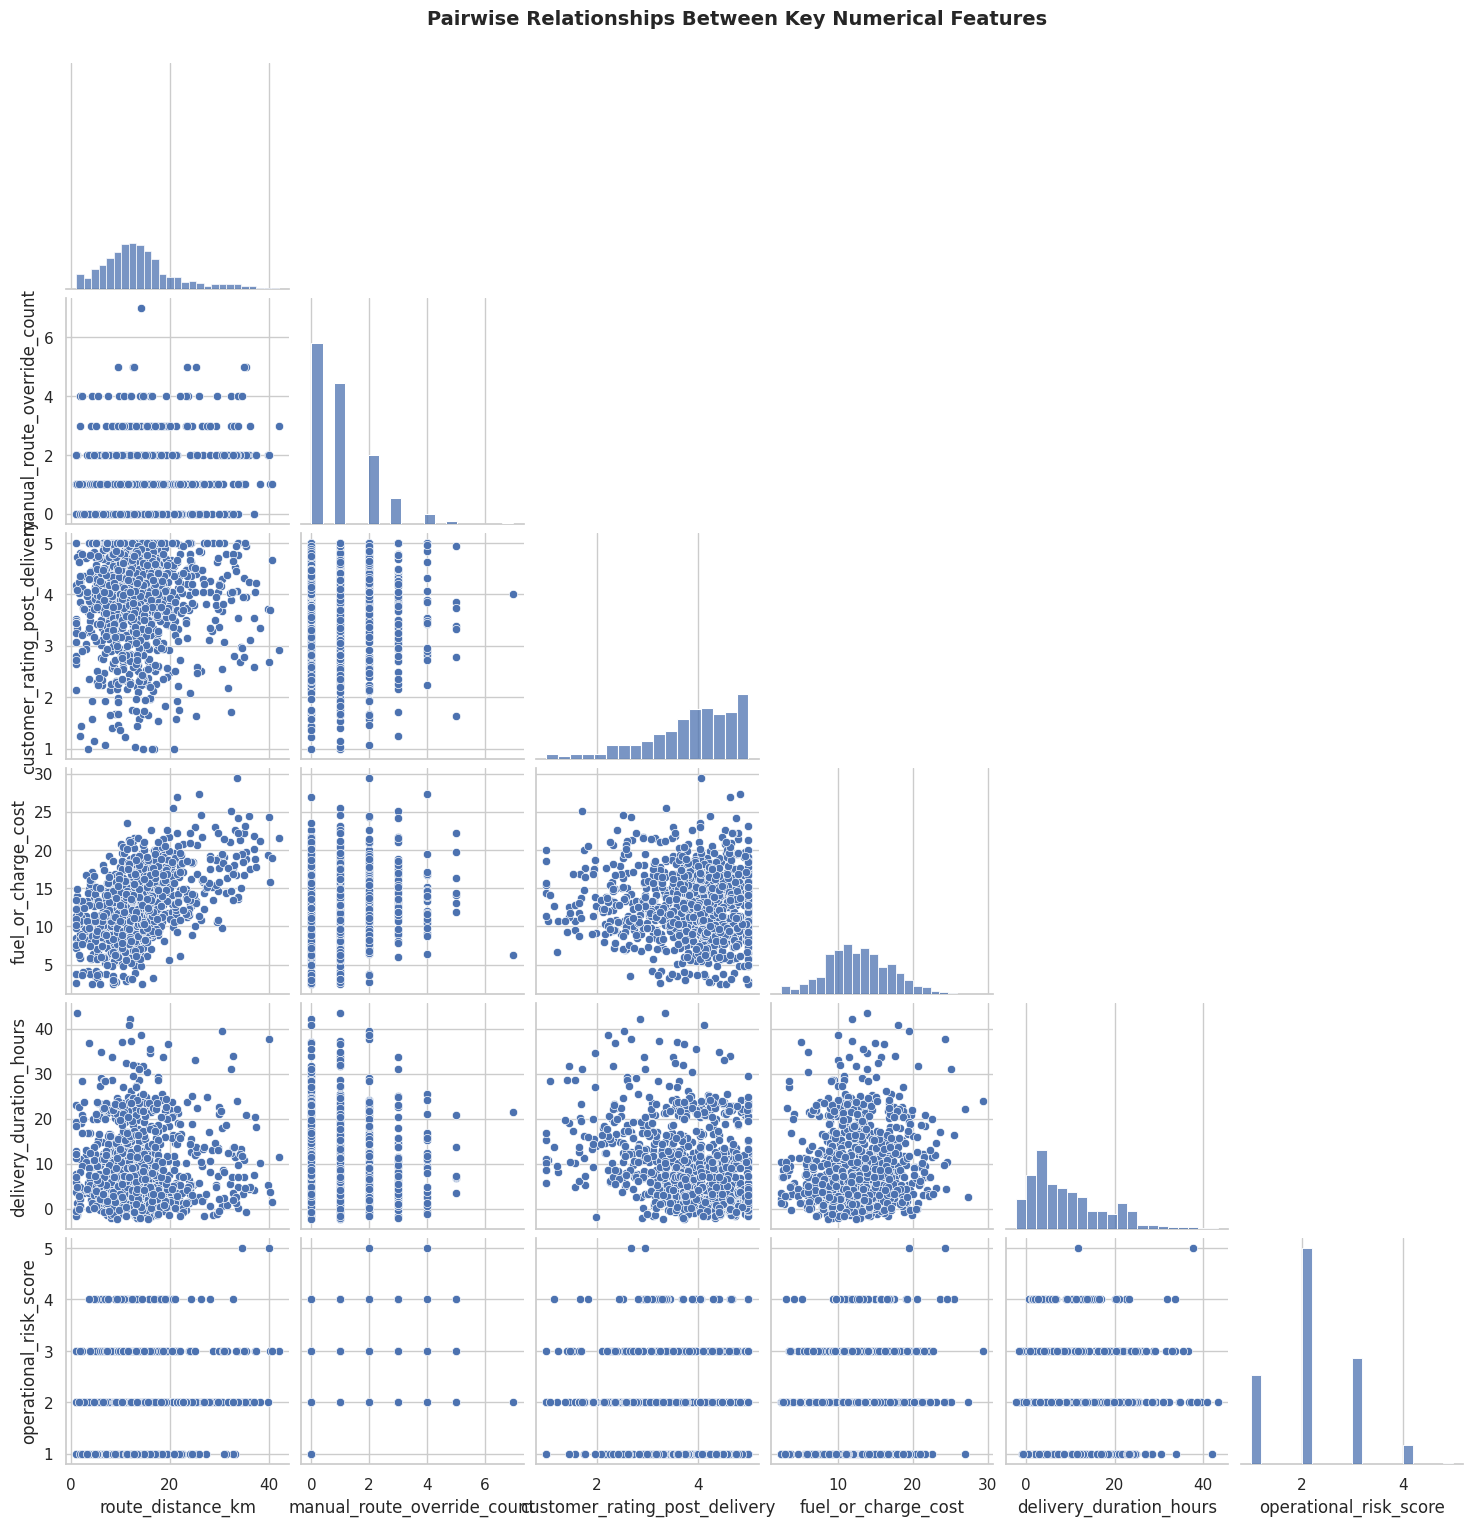

In [13]:
pairplot_features = [
    "route_distance_km",
    "manual_route_override_count",
    "customer_rating_post_delivery",
    "fuel_or_charge_cost",
    "delivery_duration_hours",
    "operational_risk_score"
]

pairplot_data = master_df[pairplot_features].dropna()

sns.pairplot(pairplot_data, diag_kind="hist", corner=True)
plt.suptitle("Pairwise Relationships Between Key Numerical Features", y=1.02, fontsize=14, fontweight="bold")
plt.show()

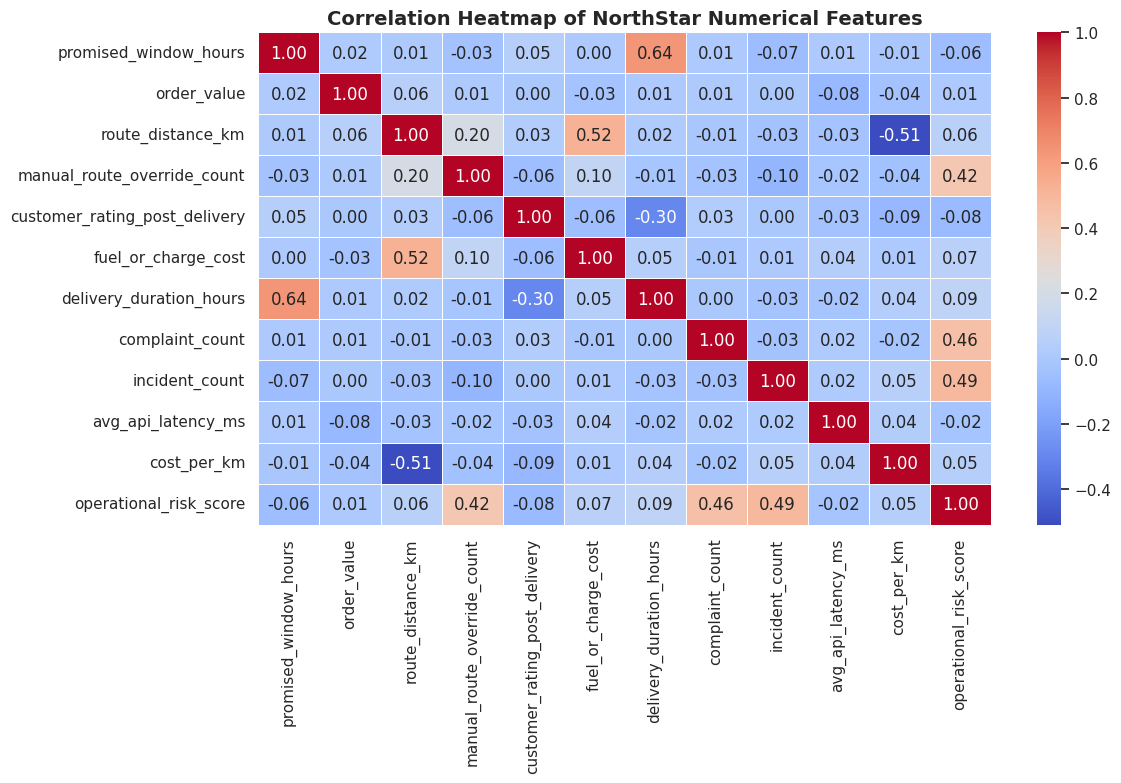

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of NorthStar Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

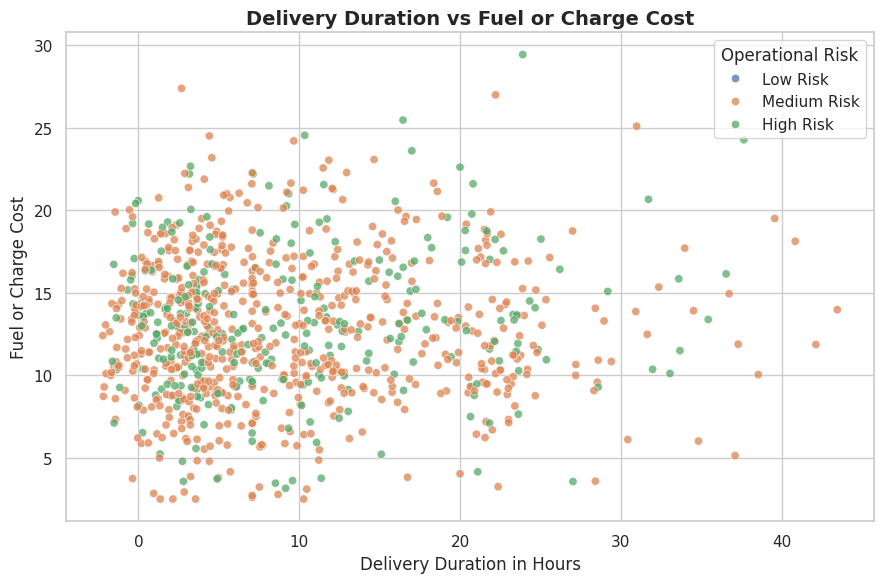

In [15]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=master_df,
    x="delivery_duration_hours",
    y="fuel_or_charge_cost",
    hue="operational_risk_category",
    alpha=0.75
)
plt.title("Delivery Duration vs Fuel or Charge Cost", fontsize=14, fontweight="bold")
plt.xlabel("Delivery Duration in Hours")
plt.ylabel("Fuel or Charge Cost")
plt.legend(title="Operational Risk")
plt.tight_layout()
plt.show()

## Section 2 summary

*  Several NorthStar datasets are combined into a single analytical view by the Python analysis. Instead of analysing each dataset independently, this enables comparisons of orders, deliveries, customers, drivers, cars, hubs, complaints, incidents, and app events

* The data integrity checks verify whether any delivery matches were missing and whether the combined dataframe maintained the anticipated quantity of order information. Delivery duration, complaint flag, incident flag, cost per km, and operational risk category are examples of operationally valuable variables that are included during the feature engineering process

* A statistical view of the dataset, including averages, variation, minimum and maximum values, and quantiles, is offered by the Pandas and NumPy summaries. NorthStar may encounter more delivery issues, complaints, incidents, or cost inefficiencies in certain areas, as shown by the service type and hub summaries

* By displaying correlations between route distance, route overrides, customer rating, delivery cost, delivery duration, and operational risk, the visualisations bolster the numerical analysis. These results contribute to the broader goal of the case study, which is to pinpoint the reasons underlying operational inefficiencies, delays, complaints, and failures
